# Контрольная классификация Zhu-Net: Cats vs Dogs (grayscale, 256×256) — V02

## Цель

Верификация обучаемости архитектуры Zhu-Net на задаче семантической классификации
(серия 1 ВКР) перед применением к стеганоанализу (серии 2–3).

## Описание эксперимента

Реализация контрольной классификации «кошки vs собаки» на архитектуре Zhu-Net V02 — верификацию обучаемости модели на семантической задаче (серия 1 ВКР) перед применением к стеганоанализу в сериях 2–3.

Zhu-Net (Zhu et al., 2021) построена на базе ResNeSt-блоков с механизмом Split-Attention (radix=2). Внутри каждого блока входной тензор обрабатывается свёрткой с удвоенным числом выходных каналов, затем разбивается на две параллельные ветви. Глобальная статистика обеих ветвей агрегируется через GAP и проходит через два FC-слоя, после чего Softmax-нормировка формирует веса, определяющие вклад каждой ветви в итоговое представление. В отличие от SE-блока, где Sigmoid масштабирует каналы независимо, Split-Attention вынуждает сеть делать конкурентный выбор между ветвями — сумма весов равна единице.

Датасет — Kaggle Cats vs Dogs: 1999 grayscale-изображений 256×256 (999 кошек, 1000 собак), разбиение holdout 70/15/15. Аугментации — горизонтальное и вертикальное отражение. Обучение: Adam + CosineAnnealingLR (1e-3 → 1e-5), CrossEntropyLoss, gradient clipping (max_norm=1.0), Dropout(0.3) перед FC, 35 эпох.

## Конфигурация эксперимента (серия 1)

| Параметр | Значение |
|---|---|
| **Архитектура** | Zhu-Net (ResNeSt + Split-Attention, radix=2) |
| **Входные данные** | Grayscale, 256×256, 1 канал |
| **Датасет** | Cats-vs-Dogs-Gray: Cat≈1000, Dog≈1000 |
| **Разбиение** | Holdout: Train 70% / Val 15% / Test 15% |
| **Batch size** | 32 |
| **Learning rate** | 1e-3 → 1e-5 (CosineAnnealingLR) |
| **Эпох** | 35 |
| **HPF** | Обучаемый (Kaiming init) + BN + ReLU |
| **Оптимизатор** | Adam, weight_decay=1e-4 |
| **Loss** | CrossEntropyLoss |
| **Dropout** | Dropout(0.3) перед FC |
| **Grad clipping** | max_norm=1.0 |

In [1]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Импорт библиотек и глобальные настройки

import os
import json
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# 2. Глобальные настройки

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Константы
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 35
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Пути
DATASET_PATH = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
SAVE_DIR = "/content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02"
os.makedirs(SAVE_DIR, exist_ok=True)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Устройство: cuda
GPU: NVIDIA A100-SXM4-40GB
Память: 42.41 GB


In [4]:
# 3. Загрузка и анализ датасета

dataset_root = Path(DATASET_PATH)
print(f"Сканирование: {dataset_root}")

data = []
for label_name, label_num in [("cat", 0), ("dog", 1)]:
    folder = dataset_root / label_name
    if folder.exists():
        for img_path in sorted(folder.glob("*.*")):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                data.append({
                    "path": str(img_path),
                    "label": label_name,
                    "label_num": label_num,
                    "filename": img_path.name,
                })
        count = len([d for d in data if d["label"] == label_name])
        print(f"  {label_name}: {count}")
    else:
        print(f"  Папка не найдена: {folder}")

df = pd.DataFrame(data)
print(f"\nВсего изображений: {len(df)}")
print(f"Баланс классов:")
print(df["label"].value_counts())

# Разделение: 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

print(f"\nРазделение:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Сканирование: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
  cat: 999
  dog: 1000

Всего изображений: 1999
Баланс классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Разделение:
  Train: 1399 (70.0%)
  Val:   300 (15.0%)
  Test:  300 (15.0%)


In [5]:
# 4. АРХИТЕКТУРА Zhu-Net  (контрольная классификация)
#
# Реализован Split-Attention (radix=2),
# HPF обучаемый + ReLU (семантическая задача).
#
# Структура:
#   HPF (1→64, 5×5) + BN + ReLU
#   ResNeStBlock(64→64,   stride=1)  — Split-Attention radix=2
#   ResNeStBlock(64→128,  stride=2)
#   ResNeStBlock(128→256, stride=2)
#   ResNeStBlock(256→512, stride=2)
#   GAP → Dropout(0.3) → FC(512, 2)


class RadixSoftmax(nn.Module):
    """Нормировка весов ветвей Split-Attention.
    radix=1 → Sigmoid; radix>1 → Softmax по оси ветвей."""
    def __init__(self, radix, groups):
        super().__init__()
        self.radix = radix
        self.groups = groups

    def forward(self, x):
        batch = x.size(0)
        if self.radix > 1:
            x = x.view(batch, self.groups, self.radix, -1)
            x = torch.softmax(x, dim=2)
            x = x.reshape(batch, -1, 1, 1)
        else:
            x = torch.sigmoid(x.unsqueeze(2))
        return x


class SplitAttentionConv2d(nn.Module):
    """
    Свёрточный слой с механизмом Split-Attention (ResNeSt, Zhang et al. 2020).

    1. Свёртка → out_ch*radix каналов
    2. Разбивка на radix ветвей
    3. Поэлементная сумма ветвей → GAP
    4. FC1 → ReLU → FC2 → RadixSoftmax → веса ветвей
    5. Взвешенная сумма ветвей → выход
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1,
                 groups=1, radix=2, reduction=4):
        super().__init__()
        self.radix = radix
        self.out_ch = out_ch

        # Свёртка с radix*out_ch выходными каналами
        self.conv = nn.Conv2d(in_ch, out_ch * radix, kernel_size,
                              stride=stride, padding=padding,
                              groups=groups * radix, bias=False)
        self.bn0 = nn.BatchNorm2d(out_ch * radix)
        self.relu = nn.ReLU(inplace=True)

        # Attention FC
        inter_ch = max(out_ch // reduction, 32)
        self.fc1 = nn.Linear(out_ch, inter_ch)

        self.fc2 = nn.Linear(inter_ch, out_ch * radix)
        self.rsoftmax = RadixSoftmax(radix, groups)

    def forward(self, x):
        # 1. Свёртка → [B, out_ch*radix, H, W]
        x = self.relu(self.bn0(self.conv(x)))

        # 2. Разбивка на radix ветвей
        batch, _, H, W = x.shape
        splitted = torch.split(x, self.out_ch, dim=1)  # radix × [B, out_ch, H, W]

        # 3. Суммирование ветвей → GAP
        gap = sum(splitted)                             # [B, out_ch, H, W]
        gap = gap.mean(dim=[2, 3])                      # [B, out_ch]

        # 4. Attention: FC1 → ReLU → FC2 → RadixSoftmax
        gap = self.relu(self.fc1(gap))                       # [B, inter_ch]
        atten = self.fc2(gap)                           # [B, out_ch*radix]
        atten = self.rsoftmax(atten)                    # [B, radix*out_ch, 1, 1]
        atten = torch.split(atten, self.out_ch, dim=1)  # radix × [B, out_ch, 1, 1]

        # 5. Взвешенная сумма ветвей
        out = sum(a * s for a, s in zip(atten, splitted))
        return out.contiguous()


class ResNeStBlock(nn.Module):
    """
    Остаточный блок с Split-Attention (ResNeSt).
    Conv(1×1) → SplitAttentionConv2d(3×3) → Conv(1×1) + shortcut → ReLU
    """
    expansion = 4

    def __init__(self, in_ch, out_ch, stride=1, radix=2, groups=1):
        super().__init__()
        mid_ch = out_ch // self.expansion if out_ch >= 64 else out_ch

        # Bottleneck
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_ch)
        self.relu1 = nn.ReLU(inplace=True)

        self.sa = SplitAttentionConv2d(
            mid_ch, mid_ch, kernel_size=3, stride=stride,
            padding=1, groups=groups, radix=radix
        )
        self.bn2 = nn.BatchNorm2d(mid_ch)
        self.relu2 = nn.ReLU(inplace=True)

        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_ch)
        self.relu3 = nn.ReLU(inplace=True)

        # Shortcut
        if stride != 1 or in_ch != out_ch:
            sc = []
            if stride > 1:
                sc.append(nn.AvgPool2d(stride, stride, ceil_mode=True))
            sc += [nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch)]
            self.shortcut = nn.Sequential(*sc)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.sa(out)))
        out = self.bn3(self.conv3(out))
        return self.relu3(out + identity)


class ZhuNet_V02(nn.Module):
    """
    Zhu-Net V02 для контрольной классификации (Cats vs Dogs).

    Вход: [B, 1, 256, 256] → Выход: [B, 2] (логиты для CrossEntropyLoss)

    Архитектура:
    - Обучаемый HPF (Conv2d 5×5, 1→64) + BN + ReLU
    - 4 ResNeSt-блока с Split-Attention (radix=2): 64→128→256→512
    - GAP → Dropout(0.3) → FC(512, 2)

    Для стеганоанализа HPF заменяется на фильтр Кёнига + Tanh+Abs.
    """
    def __init__(self, num_classes=2, radix=2):
        super().__init__()

        # HPF: обучаемый (контрольная задача — семантическая)
        self.hpf = nn.Conv2d(1, 64, kernel_size=5, padding=2, bias=False)
        self.hpf_bn = nn.BatchNorm2d(64)
        self.hpf_relu = nn.ReLU(inplace=True)

        # 4 ResNeSt-блока с Split-Attention
        self.layer1 = ResNeStBlock(64,  64,  stride=1, radix=radix)
        self.layer2 = ResNeStBlock(64,  128, stride=2, radix=radix)
        self.layer3 = ResNeStBlock(128, 256, stride=2, radix=radix)
        self.layer4 = ResNeStBlock(256, 512, stride=2, radix=radix)

        # Классификатор
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # HPF + BN + ReLU
        x = self.hpf(x)
        x = self.hpf_bn(x)
        x = self.hpf_relu(x)

        # ResNeSt-блоки с Split-Attention
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Классификатор
        x = self.gap(x).view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


# Создание и проверка модели
model = ZhuNet_V02(num_classes=2, radix=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Zhu-Net V02 создана (Split-Attention, radix=2)")
print(f"  Обучаемых параметров: {n_params:,}")

test_input = torch.randn(1, 1, IMAGE_SIZE, IMAGE_SIZE)
test_output = model(test_input)
print(f"  Вход:  {test_input.shape}")
print(f"  Выход: {test_output.shape}")

Zhu-Net V02 создана (Split-Attention, radix=2)
  Обучаемых параметров: 530,978
  Вход:  torch.Size([1, 1, 256, 256])
  Выход: torch.Size([1, 2])


In [6]:
# 5. Датасет и загрузчики

class CatsDogsDataset(Dataset):
    """Датасет Cats vs Dogs (grayscale, 256×256)."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            if self.transform:
                img = self.transform(img)
            label = torch.tensor(row["label_num"], dtype=torch.long)
            return img, label
        except Exception as e:
            print(f"Ошибка загрузки {row['path']}: {e}")
            img = torch.zeros(1, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.long)
            return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = CatsDogsDataset(train_df, train_transform)
val_dataset   = CatsDogsDataset(val_df,   val_transform)
test_dataset  = CatsDogsDataset(test_df,  val_transform)

print(f"Датасеты: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

loader_kwargs = dict(
    batch_size=BATCH_SIZE, num_workers=4,
    pin_memory=True, prefetch_factor=2, persistent_workers=True
)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

print(f"Batch size: {BATCH_SIZE} | Train batches: {len(train_loader)}")

Датасеты: Train=1399, Val=300, Test=300
Batch size: 32 | Train batches: 44


In [7]:
# 6. Функции обучения и оценки

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Eval", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc  = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels, all_probs

In [8]:
# 7. Основной цикл обучения

model = ZhuNet_V02(num_classes=2, radix=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_auc": []
}

best_val_auc = 0.0
best_epoch = 0
best_model_state = None

print(f"{'='*60}")
print(f"ОБУЧЕНИЕ Zhu-Net V02 (контрольная классификация)")
print(f"{'='*60}")
print(f"Эпох: {EPOCHS} | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}")
print(f"Параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Split-Attention: radix=2")
print(f"Сохранение: {SAVE_DIR}")
print(f"{'='*60}\n")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {lr_now:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  → Лучшая модель (Val AUC: {val_auc:.4f})")

print(f"\n{'='*60}")
print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучшая Val AUC: {best_val_auc:.4f} (эпоха {best_epoch})")
print(f"{'='*60}")

model.load_state_dict(best_model_state)
torch.save(best_model_state, os.path.join(SAVE_DIR, "zhunet_v02_best_model.pth"))
print(f"Модель сохранена: {SAVE_DIR}/zhunet_v02_best_model.pth")

ОБУЧЕНИЕ Zhu-Net V02 (контрольная классификация)
Эпох: 35 | LR: 0.001 | Batch: 32
Параметров: 530,978
Split-Attention: radix=2
Сохранение: /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02



Epoch  1/35 | Train Loss: 0.7411 Acc: 0.5954 | Val Loss: 0.7675 Acc: 0.5067 AUC: 0.5138 | LR: 0.000998
  → Лучшая модель (Val AUC: 0.5138)


Epoch  2/35 | Train Loss: 0.6920 Acc: 0.6190 | Val Loss: 0.8911 Acc: 0.5267 AUC: 0.6655 | LR: 0.000992
  → Лучшая модель (Val AUC: 0.6655)


Epoch  3/35 | Train Loss: 0.6604 Acc: 0.6319 | Val Loss: 0.6519 Acc: 0.6033 AUC: 0.6826 | LR: 0.000982
  → Лучшая модель (Val AUC: 0.6826)


Epoch  4/35 | Train Loss: 0.6603 Acc: 0.6376 | Val Loss: 0.6518 Acc: 0.6267 AUC: 0.6869 | LR: 0.000968
  → Лучшая модель (Val AUC: 0.6869)


...

Epoch 31/35 | Train Loss: 0.4014 Acc: 0.8277 | Val Loss: 0.5887 Acc: 0.7200 AUC: 0.7925 | LR: 0.000042
  → Лучшая модель (Val AUC: 0.7925)


Epoch 32/35 | Train Loss: 0.4036 Acc: 0.8184 | Val Loss: 0.6033 Acc: 0.7267 AUC: 0.7864 | LR: 0.000028


Epoch 33/35 | Train Loss: 0.4105 Acc: 0.8134 | Val Loss: 0.5905 Acc: 0.7267 AUC: 0.7923 | LR: 0.000018


Epoch 34/35 | Train Loss: 0.3846 Acc: 0.8370 | Val Loss: 0.5871 Acc: 0.7300 AUC: 0.7921 | LR: 0.000012


Epoch 35/35 | Train Loss: 0.3800 Acc: 0.8363 | Val Loss: 0.5976 Acc: 0.7300 AUC: 0.7907 | LR: 0.000010

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая Val AUC: 0.7925 (эпоха 31)
Модель сохранена: /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02/zhunet_v02_best_model.pth


In [9]:
# 8. Тестирование на holdout test set

print(f"{'='*60}")
print(f"ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET")
print(f"{'='*60}")

test_loss, test_acc, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC:      {test_auc:.4f}")

p_cat  = precision_score(test_labels, test_preds, pos_label=0)
r_cat  = recall_score(test_labels, test_preds, pos_label=0)
f1_cat = f1_score(test_labels, test_preds, pos_label=0)
p_dog  = precision_score(test_labels, test_preds, pos_label=1)
r_dog  = recall_score(test_labels, test_preds, pos_label=1)
f1_dog = f1_score(test_labels, test_preds, pos_label=1)

print(f"\n{'Класс':<8s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print(f"{'Cat':<8s} {p_cat:>10.4f} {r_cat:>8.4f} {f1_cat:>8.4f}")
print(f"{'Dog':<8s} {p_dog:>10.4f} {r_dog:>8.4f} {f1_dog:>8.4f}")

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["Cat", "Dog"]))

cm = confusion_matrix(test_labels, test_preds)
print(f"Confusion Matrix:\n{cm}")

ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET



Test Loss:     0.5313
Test Accuracy: 0.7400 (74.00%)
Test AUC:      0.8346

Класс     Precision   Recall       F1
Cat          0.7045   0.8267   0.7607
Dog          0.7903   0.6533   0.7153

Classification Report:
              precision    recall  f1-score   support

         Cat       0.70      0.83      0.76       150
         Dog       0.79      0.65      0.72       150

    accuracy                           0.74       300
   macro avg       0.75      0.74      0.74       300
weighted avg       0.75      0.74      0.74       300

Confusion Matrix:
[[124  26]
 [ 52  98]]


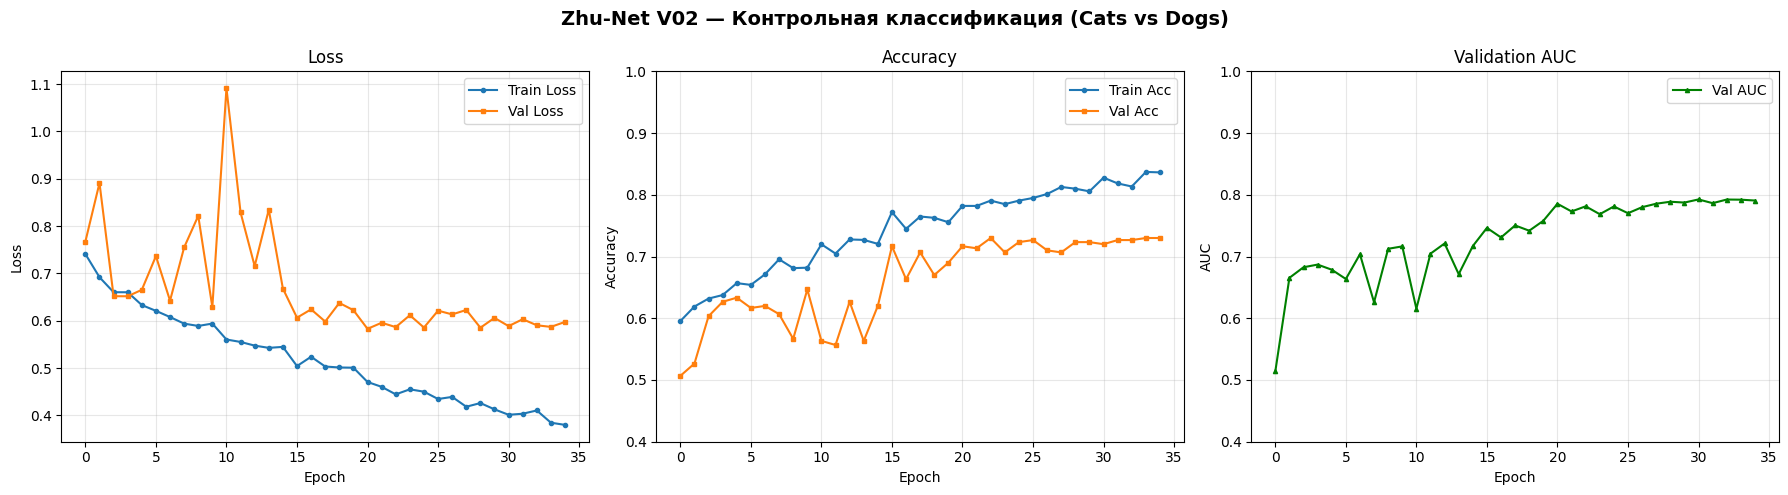

График: /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02/zhunet_v02_training_history.png


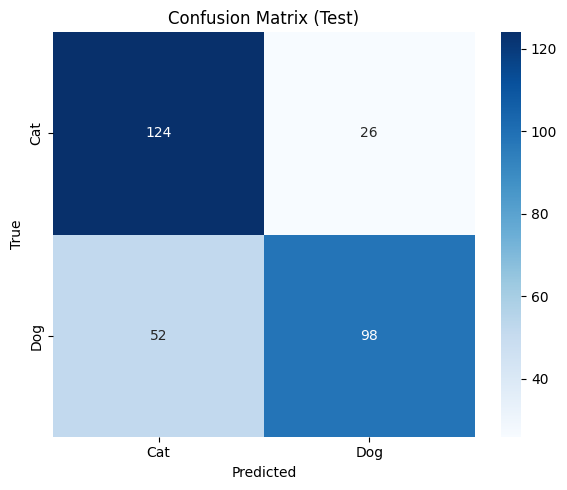

Матрица ошибок: /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02/zhunet_v02_confusion_matrix.png


In [10]:
# 9. Визуализация результатов

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Zhu-Net V02 — Контрольная классификация (Cats vs Dogs)",
             fontsize=14, fontweight="bold")

axes[0].plot(history["train_loss"], label="Train Loss", marker="o", markersize=3)
axes[0].plot(history["val_loss"],   label="Val Loss",   marker="s", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Acc", marker="o", markersize=3)
axes[1].plot(history["val_acc"],   label="Val Acc",   marker="s", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.0])

axes[2].plot(history["val_auc"], label="Val AUC", marker="^", markersize=3, color="green")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC")
axes[2].set_title("Validation AUC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.4, 1.0])

plt.tight_layout()
history_path = os.path.join(SAVE_DIR, "zhunet_v02_training_history.png")
plt.savefig(history_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"График: {history_path}")

fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"], ax=ax2)
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")
ax2.set_title("Confusion Matrix (Test)")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "zhunet_v02_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Матрица ошибок: {cm_path}")

In [11]:
# 10. Сохранение результатов

results = {
    "experiment": "Zhu-Net V02 — контрольная классификация (Cats vs Dogs, grayscale 256)",
    "architecture": "Zhu-Net (ResNeSt + Split-Attention, radix=2, 4 blocks)",
    "dataset": {
        "name": "Cats-vs-Dogs-Gray-1000",
        "total": len(df),
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
        "split": "holdout 70/15/15",
    },
    "hyperparameters": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "scheduler": "CosineAnnealingLR(eta_min=1e-5)",
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "dropout": "Dropout(0.3)",
        "grad_clip": 1.0,
        "augmentations": "HFlip(0.5), VFlip(0.5)",
        "hpf": "learnable (Kaiming init) + ReLU",
        "radix": 2,
        "seed": SEED,
    },
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "best_epoch": best_epoch,
    "results": {
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "test_auc": round(test_auc, 4),
        "precision_cat": round(p_cat, 4),
        "recall_cat": round(r_cat, 4),
        "f1_cat": round(f1_cat, 4),
        "precision_dog": round(p_dog, 4),
        "recall_dog": round(r_dog, 4),
        "f1_dog": round(f1_dog, 4),
        "confusion_matrix": cm.tolist(),
    },
    "training_history": history,
    "version_history": {
        "V01": "68.67% / AUC 0.8298 (~20M, SE instead of Split-Attn, abs+tanh in every block)",
        "V02": f"{test_acc*100:.2f}% / AUC {test_auc:.4f} (Split-Attention radix=2, ReLU, 4 blocks)",
    },
}

json_path = os.path.join(SAVE_DIR, "zhunet_v02_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Результаты: {json_path}")

print(f"\n{'='*60}")
print(f"ИТОГО: Zhu-Net V02")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC:      {test_auc:.4f}")
print(f"Лучшая эпоха:  {best_epoch}")
print(f"Параметров:    {results['trainable_parameters']:,}")
print(f"Сохранение:    {SAVE_DIR}")
print(f"{'='*60}")

Результаты: /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02/zhunet_v02_results.json

ИТОГО: Zhu-Net V02
Test Accuracy: 74.00%
Test AUC:      0.8346
Лучшая эпоха:  31
Параметров:    530,978
Сохранение:    /content/drive/MyDrive/FQW/cat-dog_zhu-net_256_V02


## Результаты обучения

Модель достигла Test Accuracy = 74.00 % и ROC-AUC = 0.8346 при 530 978 обучаемых параметрах.

Матрица ошибок [[124, 26], [52, 98]] фиксирует типичный для серии паттерн: Recall кошек (83 %) выше, чем собак (65 %). Перекос выражен слабее, чем у остальных архитектур (Yedroudj-Net: 83 % vs 53 %, GSR-Net: 78 % vs 59 %), что указывает на более сбалансированную работу Split-Attention с признаками обоих классов. Precision собак (79 %) выше, чем кошек (70 %) — модель реже ошибается, когда предсказывает «собака», но чаще пропускает собак среди реальных примеров.

Динамика обучения подтверждает устойчивую сходимость: train loss снизился с 0.74 до 0.38 за 35 эпох, val AUC монотонно рос с 0.51 до 0.79 без резких скачков. Разрыв train/val accuracy (83 % vs 73 %) указывает на умеренное переобучение, контролируемое Dropout(0.3). Лучшая модель зафиксирована на 31-й эпохе (Val AUC = 0.7925), после чего метрики стабилизировались.
